# Big Data Resume Matching with S-BERT+Cosine and TF-IDF+Jaccard
## Using parsed_resumes.csv and Web Developer Job Description

This notebook implements resume matching on a larger dataset using:
1. S-BERT embeddings with cosine similarity
2. TF-IDF with Jaccard similarity and all features
3. Text preprocessing optimized for parsed resume format
4. Web Developer job description for matching
5. Machine Learning model comparison
6. Analysis of 2400+ resumes

In [14]:
# Import necessary libraries for big data processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

# For S-BERT embeddings
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    print("Installing sentence-transformers...")
    import subprocess
    subprocess.check_call(["pip", "install", "sentence-transformers"])
    from sentence_transformers import SentenceTransformer

# For XGBoost
try:
    import xgboost as xgb
except ImportError:
    print("Installing XGBoost...")
    import subprocess
    subprocess.check_call(["pip", "install", "xgboost"])
    import xgboost as xgb

print("All libraries imported successfully!")
print("Ready for big data resume processing...")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


All libraries imported successfully!
Ready for big data resume processing...


In [2]:
# Load parsed_resumes.csv data
df = pd.read_csv('../data/raw/parsed_resumes.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Total resumes: {len(df)}")

# Display first few rows
print("\nFirst 3 rows:")
print(df.head(3))

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Basic statistics
print(f"\nDataset info:")
print(f"- Total candidates: {len(df)}")
print(f"- Unique names: {df['Person Name'].nunique()}")
print(f"- Columns with data: {df.columns[df.notna().any()].tolist()}")

# Sample data inspection
print(f"\nSample Work Experience:")
print(df['Work Experience'].iloc[0][:200] + "..." if pd.notna(df['Work Experience'].iloc[0]) else "No work experience data")

print(f"\nSample Skills:")
print(df['Skills'].iloc[0][:200] + "..." if pd.notna(df['Skills'].iloc[0]) else "No skills data")

Dataset shape: (2437, 7)
Columns: ['Person Name', 'Work Experience', 'Skills', 'Education', 'Certifications/Licenses', 'Links', 'Additional Information']
Total resumes: 2437

First 3 rows:
  Person Name                                    Work Experience  \
0           A  senior systems administrator trico products - ...   
1           B  systems administrator bios technologies - meta...   
2           C  systems administrator nord gear corporation - ...   

                                              Skills  \
0  cisco routing and switching configuration, imp...   
1  and a knack for web development. experienced i...   
2  hardware: apple, microsoft, dell, hp, ibm 10+ ...   

                                           Education  \
0  associate in drafting technology university of...   
1  bachelor of science in computer criminology fl...   
2  certificate in web development university of w...   

                             Certifications/Licenses  \
0                               

In [3]:
# Load Web Developer job description
with open('../data/job_descriptions/Web-Developer-job-description.txt', 'r', encoding='utf-8') as file:
    job_description = file.read()

print("Web Developer Job Description:")
print("=" * 50)
print(job_description)
print("=" * 50)

# Text preprocessing functions optimized for parsed resume format
def clean_text(text):
    """Clean and preprocess text data"""
    if pd.isna(text) or text == '':
        return ''
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs, emails, and phone numbers
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\b\d{3}[-.]\d{3}[-.]\d{4}\b', ' ', text)
    text = re.sub(r'\b\d{10}\b', ' ', text)
    
    # Remove special characters and digits but keep important punctuation
    text = re.sub(r'[^a-zA-Z\s\-\+\#]', ' ', text)
    
    # Remove extra whitespaces
    text = ' '.join(text.split())
    
    return text

def preprocess_text(text):
    """Advanced text preprocessing with tokenization and lemmatization"""
    if pd.isna(text) or text == '':
        return ''
    
    # Clean text
    text = clean_text(text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords but keep technical terms
    stop_words = set(stopwords.words('english'))
    # Remove common non-informative words but keep technical terms
    tech_stopwords = {'will', 'would', 'could', 'should', 'may', 'might', 'must'}
    stop_words.update(tech_stopwords)
    
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

print("Text preprocessing functions defined successfully!")

Web Developer Job Description:

Job Title: Web Developer
Company: Not specified
Department: engineering
Level: intern
Work Mode: remote
Location: Not specified
Salary: EUR1K - EUR2K
Job Type: internship
Description: We need web developers with expertise in at least 1 of the following skills - Node.js, Nest.js, Vue.js, Laravel.

Selected Intern's day-to-day responsibilities include creating websites through Node.js, Nest.js, Vue.js, etc.

Please do not apply if you do not have expertise.

We are looking only for serious interns. To prevent mutual waste of time, energy, and resources, any intern not working seriously can be removed with immediate effect without any benefits being given. We will give intern certificates, etc., to only those who have contributed sufficiently.
                  
Text preprocessing functions defined successfully!


In [4]:
# Combine all relevant resume text content from parsed format
def combine_resume_text_parsed(row):
    """Combine all relevant text fields from parsed resume format"""
    text_fields = [
        'Work Experience', 'Skills', 'Education', 
        'Certifications/Licenses', 'Additional Information'
    ]
    
    combined_text = []
    for field in text_fields:
        if field in row and pd.notna(row[field]) and str(row[field]).strip():
            # Clean and add field content
            field_content = str(row[field]).strip()
            if field_content and field_content.lower() not in ['nan', 'none', 'null']:
                combined_text.append(field_content)
    
    return ' '.join(combined_text)

print("Processing big dataset - this may take a while...")

# Create combined resume text
df['combined_text'] = df.apply(combine_resume_text_parsed, axis=1)

# Remove rows with empty combined text
df_cleaned = df[df['combined_text'].str.len() > 0].copy().reset_index(drop=True)
print(f"Removed {len(df) - len(df_cleaned)} resumes with no useful content")

# Preprocess job description
job_description_processed = preprocess_text(job_description)
print("Processed Job Description:")
print(job_description_processed)

# Preprocess resume texts (this will take time for big dataset)
print(f"\nProcessing {len(df_cleaned)} resume texts...")
df_cleaned['processed_text'] = df_cleaned['combined_text'].apply(preprocess_text)

# Remove empty processed texts
df_cleaned = df_cleaned[df_cleaned['processed_text'].str.len() > 0].reset_index(drop=True)

print(f"\nFinal dataset shape after preprocessing: {df_cleaned.shape}")
print(f"Sample processed resume text:")
print(df_cleaned['processed_text'].iloc[0][:200] + "...")

# Save memory by removing unnecessary columns
if 'Links' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['Links'])

print(f"Dataset ready for similarity matching!")

Processing big dataset - this may take a while...
Removed 102 resumes with no useful content
Processed Job Description:
job title web developer company specified department engineering level intern work mode remote location specified salary eur eur job type internship description need web developer expertise least following skill node nest vue laravel selected intern day-to-day responsibility include creating website node nest vue etc please apply expertise looking serious intern prevent mutual waste time energy resource intern working seriously removed immediate effect without benefit given give intern certificate etc contributed sufficiently

Processing 2335 resume texts...

Final dataset shape after preprocessing: (2335, 9)
Sample processed resume text:
senior system administrator trico product brownsville october october senior system administrator trico product corporation technical lead infrastructure group following location north america locatio...
Dataset ready for similarity 

## Method 1: S-BERT + Cosine Similarity (Big Data Processing)

In [5]:
# Initialize S-BERT model for big data processing
print("Loading S-BERT model for big data processing...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')  # Lightweight model for better performance
print("S-BERT model loaded successfully!")

# Generate embeddings for job description
print("Generating job description embedding...")
job_embedding = sbert_model.encode([job_description_processed])

# Generate embeddings for all resumes (process in batches for memory efficiency)
print(f"Generating embeddings for {len(df_cleaned)} resumes...")
batch_size = 100  # Process in batches to manage memory
resume_embeddings = []

for i in range(0, len(df_cleaned), batch_size):
    batch_end = min(i + batch_size, len(df_cleaned))
    batch_texts = df_cleaned['processed_text'].iloc[i:batch_end].tolist()
    batch_embeddings = sbert_model.encode(batch_texts)
    resume_embeddings.extend(batch_embeddings)
    
    if (i // batch_size + 1) % 10 == 0:
        print(f"Processed {batch_end}/{len(df_cleaned)} resumes...")

resume_embeddings = np.array(resume_embeddings)
print(f"Generated embeddings for {len(resume_embeddings)} resumes")

# Calculate cosine similarity between job description and all resumes
print("Calculating cosine similarities...")
sbert_similarities = cosine_similarity(job_embedding, resume_embeddings)[0]

# Add S-BERT similarity scores to dataframe
df_cleaned['sbert_similarity'] = sbert_similarities

# Sort by S-BERT similarity (descending)
df_sbert_ranked = df_cleaned.sort_values('sbert_similarity', ascending=False).reset_index(drop=True)

print(f"S-BERT similarity scores calculated!")
print(f"Top 10 matches by S-BERT similarity:")
print("=" * 80)
for i in range(min(10, len(df_sbert_ranked))):
    print(f"Rank {i+1}: {df_sbert_ranked.iloc[i]['Person Name']} - Similarity: {df_sbert_ranked.iloc[i]['sbert_similarity']:.4f}")
    # Show sample skills if available
    skills_sample = str(df_sbert_ranked.iloc[i]['Skills'])[:100] + "..." if pd.notna(df_sbert_ranked.iloc[i]['Skills']) else "No skills listed"
    print(f"Skills: {skills_sample}")
    print("-" * 60)

print(f"\nS-BERT Similarity Statistics:")
print(f"Mean: {df_cleaned['sbert_similarity'].mean():.4f}")
print(f"Std: {df_cleaned['sbert_similarity'].std():.4f}")
print(f"Min: {df_cleaned['sbert_similarity'].min():.4f}")
print(f"Max: {df_cleaned['sbert_similarity'].max():.4f}")
print(f"Top 1% threshold: {np.percentile(df_cleaned['sbert_similarity'], 99):.4f}")

Loading S-BERT model for big data processing...
S-BERT model loaded successfully!
Generating job description embedding...
Generating embeddings for 2335 resumes...
Processed 1000/2335 resumes...
Processed 2000/2335 resumes...
Generated embeddings for 2335 resumes
Calculating cosine similarities...
S-BERT similarity scores calculated!
Top 10 matches by S-BERT similarity:
Rank 1: ABU - Similarity: 0.6388
Skills: front end (less than 1 year), javascript (less than 1 year), ui (less than 1 year)...
------------------------------------------------------------
Rank 2: XN - Similarity: 0.6353
Skills: html5 (1.5 years) javascript/jquery (3 years) angularjs (2-4), (2 years) node.js, requirejs, express...
------------------------------------------------------------
Rank 3: ZR - Similarity: 0.6353
Skills: html5 (1.5 years) javascript/jquery (3 years) angularjs (2-4), (2 years) node.js, requirejs, express...
------------------------------------------------------------
Rank 4: AGA - Similarity: 0.6

## Method 2: TF-IDF + Jaccard Similarity (Big Data with All Features)

In [6]:
# Jaccard similarity function
def jaccard_similarity(set1, set2):
    """Calculate Jaccard similarity between two sets"""
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

# TF-IDF Vectorization optimized for big data
print("Creating TF-IDF vectors for big dataset...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,  # Increased for big data
    ngram_range=(1, 2),
    stop_words='english',
    lowercase=True,
    min_df=2,  # Ignore terms that appear in fewer than 2 documents
    max_df=0.95,  # Ignore terms that appear in more than 95% of documents
    sublinear_tf=True  # Use sublinear tf scaling for better performance on large datasets
)

# Combine job description with all resume texts for TF-IDF
print("Preparing texts for TF-IDF transformation...")
all_texts = [job_description_processed] + df_cleaned['processed_text'].tolist()

print(f"Fitting TF-IDF on {len(all_texts)} documents...")
tfidf_matrix = tfidf_vectorizer.fit_transform(all_texts)

# Get feature names (terms)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Separate job description TF-IDF vector from resume vectors
job_tfidf = tfidf_matrix[0]
resume_tfidf = tfidf_matrix[1:]

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Matrix density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}")

# Convert TF-IDF vectors to sets of terms for Jaccard similarity
def tfidf_to_term_set(tfidf_vector, feature_names, threshold=0.01):
    """Convert TF-IDF vector to set of terms above threshold"""
    if hasattr(tfidf_vector, 'toarray'):
        tfidf_array = tfidf_vector.toarray()[0]
    else:
        tfidf_array = tfidf_vector
    return set([feature_names[i] for i, score in enumerate(tfidf_array) if score > threshold])

# Convert job description to term set
job_term_set = tfidf_to_term_set(job_tfidf, feature_names)
print(f"Job description terms: {len(job_term_set)}")
print(f"Sample job terms: {list(job_term_set)[:15]}")

# Calculate Jaccard similarity for each resume (optimized for big data)
print("Calculating Jaccard similarities for big dataset...")
jaccard_similarities = []

# Process in batches for memory efficiency
batch_size = 500
for i in range(0, resume_tfidf.shape[0], batch_size):
    batch_end = min(i + batch_size, resume_tfidf.shape[0])
    batch_similarities = []
    
    for j in range(i, batch_end):
        resume_term_set = tfidf_to_term_set(resume_tfidf[j], feature_names)
        jaccard_sim = jaccard_similarity(job_term_set, resume_term_set)
        batch_similarities.append(jaccard_sim)
    
    jaccard_similarities.extend(batch_similarities)
    
    # Progress update
    if ((i // batch_size) + 1) % 5 == 0:
        print(f"Processed {batch_end}/{resume_tfidf.shape[0]} resumes for Jaccard similarity...")

# Add Jaccard similarity scores to dataframe
df_cleaned['jaccard_similarity'] = jaccard_similarities

# Sort by Jaccard similarity (descending)
df_jaccard_ranked = df_cleaned.sort_values('jaccard_similarity', ascending=False).reset_index(drop=True)

print(f"Jaccard similarity scores calculated!")
print(f"Top 10 matches by Jaccard similarity:")
print("=" * 80)
for i in range(min(10, len(df_jaccard_ranked))):
    print(f"Rank {i+1}: {df_jaccard_ranked.iloc[i]['Person Name']} - Similarity: {df_jaccard_ranked.iloc[i]['jaccard_similarity']:.4f}")
    skills_sample = str(df_jaccard_ranked.iloc[i]['Skills'])[:100] + "..." if pd.notna(df_jaccard_ranked.iloc[i]['Skills']) else "No skills listed"
    print(f"Skills: {skills_sample}")
    print("-" * 60)

print(f"\nJaccard Similarity Statistics:")
print(f"Mean: {df_cleaned['jaccard_similarity'].mean():.4f}")
print(f"Std: {df_cleaned['jaccard_similarity'].std():.4f}")
print(f"Min: {df_cleaned['jaccard_similarity'].min():.4f}")
print(f"Max: {df_cleaned['jaccard_similarity'].max():.4f}")
print(f"Top 1% threshold: {np.percentile(df_cleaned['jaccard_similarity'], 99):.4f}")

Creating TF-IDF vectors for big dataset...
Preparing texts for TF-IDF transformation...
Fitting TF-IDF on 2336 documents...
TF-IDF matrix shape: (2336, 10000)
Number of features: 10000
Matrix density: 0.0305
Job description terms: 51
Sample job terms: ['given', 'mutual', 'department', 'energy', 'node', 'contributed', 'resource', 'removed', 'effect', 'selected', 'immediate', 'need', 'day day', 'type', 'work']
Calculating Jaccard similarities for big dataset...
Processed 2335/2335 resumes for Jaccard similarity...
Jaccard similarity scores calculated!
Top 10 matches by Jaccard similarity:
Rank 1: WG - Similarity: 0.0704
Skills: No skills listed
------------------------------------------------------------
Rank 2: AFW - Similarity: 0.0674
Skills: html 5 (3 years), javascript (3 years), css (3 years), php (1 year), jquery (3 years), react (2 year...
------------------------------------------------------------
Rank 3: ZN - Similarity: 0.0674
Skills: html 5 (3 years), javascript (3 years), cs

## Big Data Comparison and Analysis

In [7]:
# Compare the two methods on big dataset
comparison_df = pd.DataFrame({
    'Name': df_cleaned['Person Name'],
    'S-BERT_Similarity': df_cleaned['sbert_similarity'],
    'Jaccard_Similarity': df_cleaned['jaccard_similarity'],
    'Skills': df_cleaned['Skills'],
    'Work_Experience': df_cleaned['Work Experience']
})

# Add ranks for both methods
comparison_df['SBERT_Rank'] = comparison_df['S-BERT_Similarity'].rank(ascending=False, method='min')
comparison_df['Jaccard_Rank'] = comparison_df['Jaccard_Similarity'].rank(ascending=False, method='min')

# Calculate rank difference
comparison_df['Rank_Difference'] = abs(comparison_df['SBERT_Rank'] - comparison_df['Jaccard_Rank'])

# Sort by S-BERT similarity for display
comparison_df_sorted = comparison_df.sort_values('S-BERT_Similarity', ascending=False).reset_index(drop=True)

print("BIG DATA ANALYSIS - Top 15 candidates comparison:")
print("=" * 120)
print(f"{'Rank':<4} {'Name':<20} {'S-BERT':<8} {'Jaccard':<8} {'SBERT_R':<8} {'Jaccard_R':<9} {'Rank_Diff':<9}")
print("-" * 120)

for i in range(min(15, len(comparison_df_sorted))):
    row = comparison_df_sorted.iloc[i]
    name_short = str(row['Name'])[:19] if pd.notna(row['Name']) else f"Person_{i+1}"
    print(f"{i+1:<4} {name_short:<20} {row['S-BERT_Similarity']:.4f}   {row['Jaccard_Similarity']:.4f}   {int(row['SBERT_Rank']):<8} {int(row['Jaccard_Rank']):<9} {int(row['Rank_Difference']):<9}")

print("\n" + "=" * 120)

# Correlation analysis for big data
correlation = comparison_df['S-BERT_Similarity'].corr(comparison_df['Jaccard_Similarity'])
print(f"Correlation between S-BERT and Jaccard similarities: {correlation:.4f}")

# Big data statistics comparison
print(f"\nBIG DATA STATISTICS COMPARISON:")
print(f"Dataset size: {len(comparison_df)} candidates")
print(f"\nS-BERT Similarity Statistics:")
print(f"Mean: {comparison_df['S-BERT_Similarity'].mean():.4f}")
print(f"Std: {comparison_df['S-BERT_Similarity'].std():.4f}")
print(f"Min: {comparison_df['S-BERT_Similarity'].min():.4f}")
print(f"Max: {comparison_df['S-BERT_Similarity'].max():.4f}")

print(f"\nJaccard Similarity Statistics:")
print(f"Mean: {comparison_df['Jaccard_Similarity'].mean():.4f}")
print(f"Std: {comparison_df['Jaccard_Similarity'].std():.4f}")
print(f"Min: {comparison_df['Jaccard_Similarity'].min():.4f}")
print(f"Max: {comparison_df['Jaccard_Similarity'].max():.4f}")

print(f"\nRank Difference Statistics:")
print(f"Mean rank difference: {comparison_df['Rank_Difference'].mean():.2f}")
print(f"Max rank difference: {comparison_df['Rank_Difference'].max():.0f}")
print(f"Candidates with rank difference > 100: {(comparison_df['Rank_Difference'] > 100).sum()}")
print(f"Candidates with rank difference > 500: {(comparison_df['Rank_Difference'] > 500).sum()}")

# Top percentile analysis
top_1_percent = int(0.01 * len(comparison_df))
top_5_percent = int(0.05 * len(comparison_df))

print(f"\nTOP PERCENTILE ANALYSIS:")
print(f"Top 1% ({top_1_percent} candidates) S-BERT threshold: {comparison_df_sorted.iloc[top_1_percent-1]['S-BERT_Similarity']:.4f}")
print(f"Top 5% ({top_5_percent} candidates) S-BERT threshold: {comparison_df_sorted.iloc[top_5_percent-1]['S-BERT_Similarity']:.4f}")

jaccard_sorted = comparison_df.sort_values('Jaccard_Similarity', ascending=False)
print(f"Top 1% Jaccard threshold: {jaccard_sorted.iloc[top_1_percent-1]['Jaccard_Similarity']:.4f}")
print(f"Top 5% Jaccard threshold: {jaccard_sorted.iloc[top_5_percent-1]['Jaccard_Similarity']:.4f}")

BIG DATA ANALYSIS - Top 15 candidates comparison:
Rank Name                 S-BERT   Jaccard  SBERT_R  Jaccard_R Rank_Diff
------------------------------------------------------------------------------------------------------------------------
1    ABU                  0.6388   0.0645   1        7         6        
2    XN                   0.6353   0.0427   2        114       112      
3    ZR                   0.6353   0.0427   2        114       112      
4    AGA                  0.6353   0.0427   4        114       110      
5    BGH                  0.6010   0.0517   5        41        36       
6    WK                   0.5950   0.0500   6        50        44       
7    BPH                  0.5899   0.0131   7        1985      1978     
8    ADX                  0.5850   0.0250   8        804       796      
9    ACU                  0.5828   0.0365   9        214       205      
10   YG                   0.5779   0.0650   10       5         5        
11   AAN                  

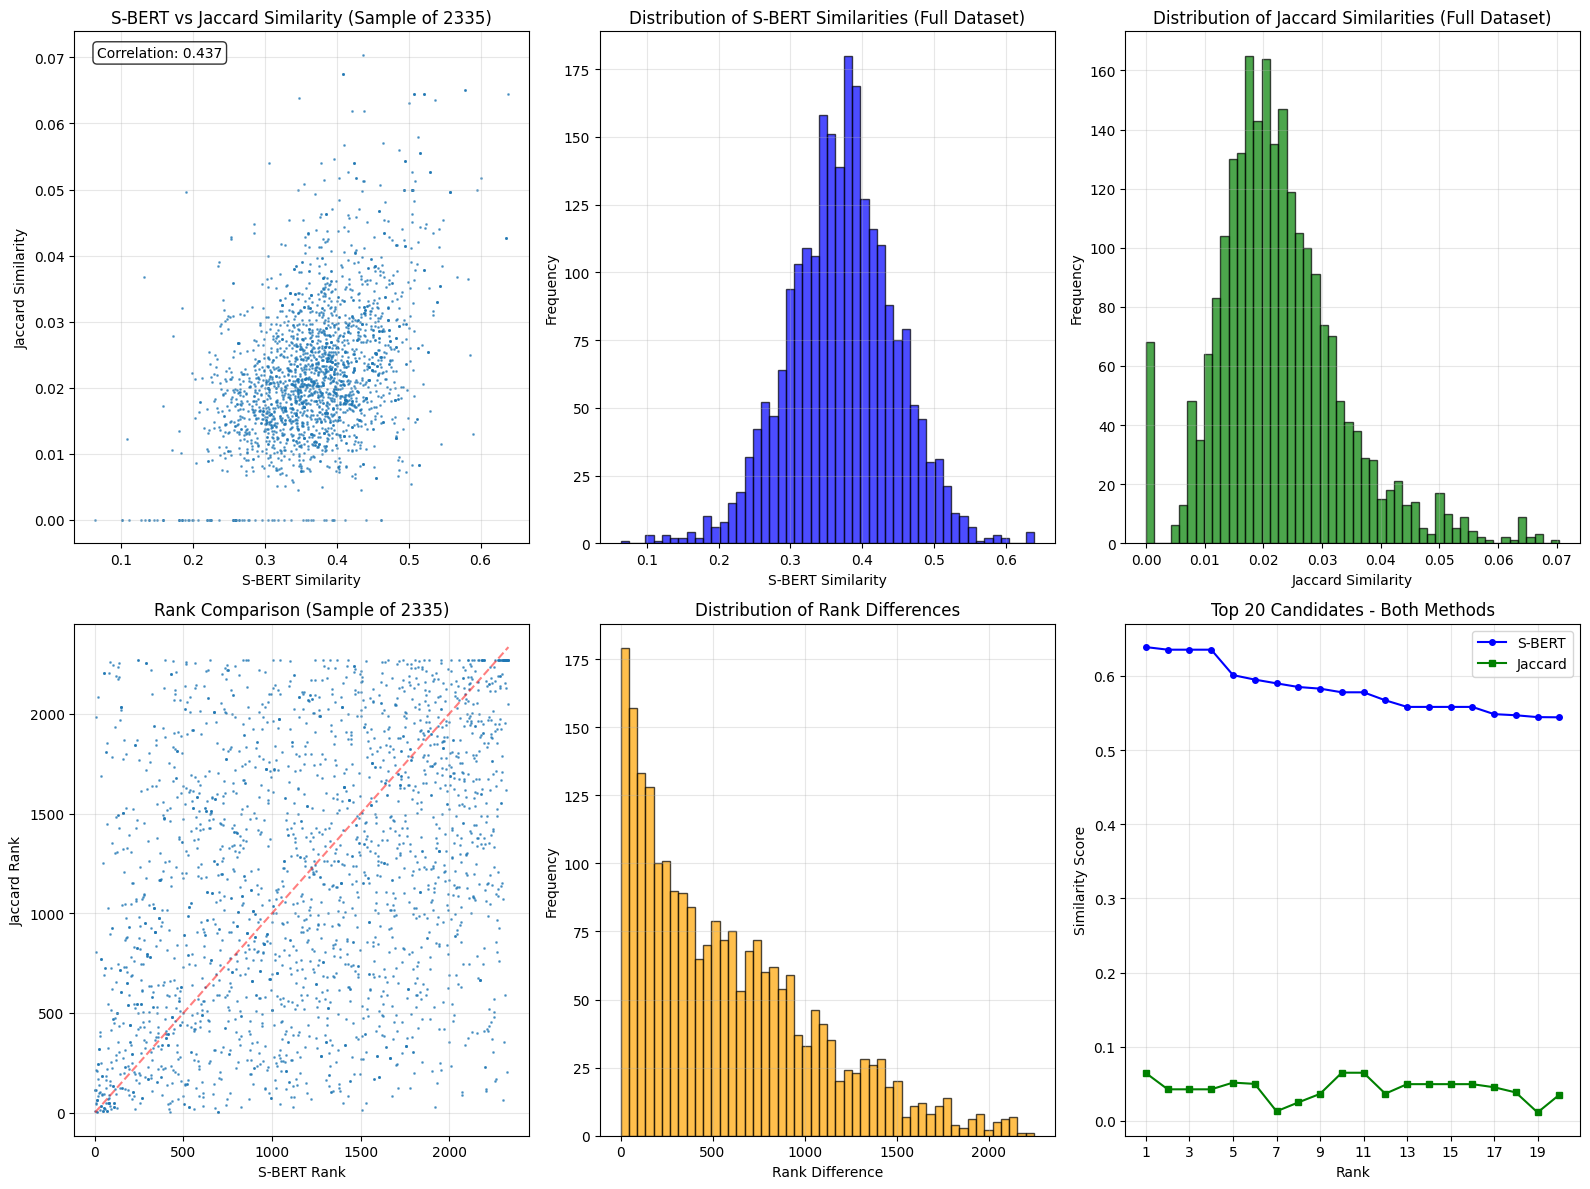

Visualization completed using sample of 2335 candidates from 2335 total candidates


In [8]:
# Big Data Visualization (sampled for performance)
sample_size = min(5000, len(comparison_df))  # Sample for visualization performance
comparison_sample = comparison_df.sample(n=sample_size, random_state=42)

plt.figure(figsize=(16, 12))

# 1. Scatter plot of similarities (sampled)
plt.subplot(2, 3, 1)
plt.scatter(comparison_sample['S-BERT_Similarity'], comparison_sample['Jaccard_Similarity'], 
           alpha=0.6, s=1)
plt.xlabel('S-BERT Similarity')
plt.ylabel('Jaccard Similarity')
plt.title(f'S-BERT vs Jaccard Similarity (Sample of {sample_size})')
plt.grid(True, alpha=0.3)
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Distribution of S-BERT similarities
plt.subplot(2, 3, 2)
plt.hist(comparison_df['S-BERT_Similarity'], bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('S-BERT Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of S-BERT Similarities (Full Dataset)')
plt.grid(True, alpha=0.3)

# 3. Distribution of Jaccard similarities
plt.subplot(2, 3, 3)
plt.hist(comparison_df['Jaccard_Similarity'], bins=50, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Jaccard Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Jaccard Similarities (Full Dataset)')
plt.grid(True, alpha=0.3)

# 4. Rank comparison (sampled)
plt.subplot(2, 3, 4)
plt.scatter(comparison_sample['SBERT_Rank'], comparison_sample['Jaccard_Rank'], 
           alpha=0.6, s=1)
plt.xlabel('S-BERT Rank')
plt.ylabel('Jaccard Rank')
plt.title(f'Rank Comparison (Sample of {sample_size})')
plt.plot([1, len(comparison_df)], [1, len(comparison_df)], 'r--', alpha=0.5)
plt.grid(True, alpha=0.3)

# 5. Rank difference distribution
plt.subplot(2, 3, 5)
plt.hist(comparison_df['Rank_Difference'], bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Rank Difference')
plt.ylabel('Frequency')
plt.title('Distribution of Rank Differences')
plt.grid(True, alpha=0.3)

# 6. Top 20 comparison
plt.subplot(2, 3, 6)
top_20 = comparison_df_sorted.head(20)
x = range(len(top_20))
plt.plot(x, top_20['S-BERT_Similarity'], 'bo-', label='S-BERT', markersize=4)
plt.plot(x, top_20['Jaccard_Similarity'], 'gs-', label='Jaccard', markersize=4)
plt.xlabel('Rank')
plt.ylabel('Similarity Score')
plt.title('Top 20 Candidates - Both Methods')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 20, 2), [f'{i+1}' for i in range(0, 20, 2)])

plt.tight_layout()
plt.show()

print(f"Visualization completed using sample of {sample_size} candidates from {len(comparison_df)} total candidates")

In [9]:
# Detailed analysis of top candidates from big dataset
print("BIG DATA - DETAILED ANALYSIS OF TOP 10 CANDIDATES")
print("=" * 100)

web_dev_keywords = ['javascript', 'node', 'vue', 'nest', 'laravel', 'web', 'frontend', 'backend', 
                   'html', 'css', 'react', 'angular', 'php', 'python', 'django', 'flask']

# Get top 10 candidates from comparison_df_sorted
for i in range(min(10, len(comparison_df_sorted))):
    candidate_name = comparison_df_sorted.iloc[i]['Name']
    
    # Find the candidate in df_cleaned to get all their details
    if pd.notna(candidate_name):
        candidate_match = df_cleaned[df_cleaned['Person Name'] == candidate_name]
    else:
        candidate_match = df_cleaned.iloc[[i]]  # Fallback to index if name is NaN
    
    if len(candidate_match) > 0:
        candidate = candidate_match.iloc[0]
        
        print(f"\n{i+1}. {candidate['Person Name'] if pd.notna(candidate['Person Name']) else f'Candidate_{i+1}'}")
        print(f"   S-BERT Score: {candidate['sbert_similarity']:.4f}")
        print(f"   Jaccard Score: {candidate['jaccard_similarity']:.4f}")
        
        # Work Experience (first 150 chars)
        work_exp = str(candidate['Work Experience'])[:150] + "..." if pd.notna(candidate['Work Experience']) else "No work experience listed"
        print(f"   Work Experience: {work_exp}")
        
        # Skills (first 100 chars)
        skills = str(candidate['Skills'])[:100] + "..." if pd.notna(candidate['Skills']) else "No skills listed"
        print(f"   Skills: {skills}")
        
        # Check for web development keywords in combined text
        combined_text = candidate['combined_text'].lower() if pd.notna(candidate['combined_text']) else ""
        matching_keywords = [kw for kw in web_dev_keywords if kw in combined_text]
        print(f"   Web Dev Keywords Found: {matching_keywords}")
        
        # Education (first 80 chars)
        education = str(candidate['Education'])[:80] + "..." if pd.notna(candidate['Education']) else "No education info"
        print(f"   Education: {education}")
        
        print("-" * 80)

# Combined scoring approach for big data
print("\nBIG DATA - COMBINED SCORING APPROACH")
print("=" * 60)

# Normalize scores to 0-1 range
scaler = MinMaxScaler()
comparison_df['SBERT_Normalized'] = scaler.fit_transform(comparison_df[['S-BERT_Similarity']])
comparison_df['Jaccard_Normalized'] = scaler.fit_transform(comparison_df[['Jaccard_Similarity']])

# Combined score (equal weights)
comparison_df['Combined_Score'] = (comparison_df['SBERT_Normalized'] + comparison_df['Jaccard_Normalized']) / 2

# Sort by combined score
final_ranking = comparison_df.sort_values('Combined_Score', ascending=False).reset_index(drop=True)

print("Top 15 candidates using combined scoring (Big Data):")
print("=" * 100)
print(f"{'Rank':<4} {'Name':<20} {'Combined':<9} {'S-BERT':<8} {'Jaccard':<8}")
print("-" * 100)

for i in range(min(15, len(final_ranking))):
    row = final_ranking.iloc[i]
    name_short = str(row['Name'])[:19] if pd.notna(row['Name']) else f"Candidate_{i+1}"
    print(f"{i+1:<4} {name_short:<20} {row['Combined_Score']:.4f}    {row['S-BERT_Similarity']:.4f}   {row['Jaccard_Similarity']:.4f}")

print(f"\nBig Data Processing Summary:")
print(f"Total candidates processed: {len(final_ranking)}")
print(f"Top 1% candidates: {int(0.01 * len(final_ranking))}")
print(f"Top 5% candidates: {int(0.05 * len(final_ranking))}")
print(f"Combined score range: {final_ranking['Combined_Score'].min():.4f} - {final_ranking['Combined_Score'].max():.4f}")

BIG DATA - DETAILED ANALYSIS OF TOP 10 CANDIDATES

1. ABU
   S-BERT Score: 0.6388
   Jaccard Score: 0.0645
   Work Experience: front end web developer/designer legwork studio - denver, co may 2010 to september 2018 for 8 years (1 year as an intern) i served as a web developer ...
   Skills: front end (less than 1 year), javascript (less than 1 year), ui (less than 1 year)...
   Web Dev Keywords Found: ['javascript', 'web']
   Education: bachelor's in interactive media & design art institute of colorado denver, coaug...
--------------------------------------------------------------------------------

2. XN
   S-BERT Score: 0.6353
   Jaccard Score: 0.0427
   Work Experience: intern - front end developer w.b. technology, inc december 2017 to january 2018 an intern as a front-end developer on a given projects to design, debu...
   Skills: html5 (1.5 years) javascript/jquery (3 years) angularjs (2-4), (2 years) node.js, requirejs, express...
   Web Dev Keywords Found: ['javascript', 'node',

## Big Data Machine Learning Model Comparison

Now we'll apply ML algorithms to the large dataset for comprehensive candidate evaluation.

In [10]:
# Feature Engineering for Big Data ML Models
print("Creating features for big data ML models...")

# Create additional features optimized for parsed resume format
ml_features_df = final_ranking.copy()

# Enhanced keyword lists for web development
web_dev_keywords = ['javascript', 'node', 'vue', 'nest', 'laravel', 'web', 'frontend', 'backend', 
                   'html', 'css', 'react', 'angular', 'php', 'python', 'django', 'flask', 'express']

programming_languages = ['javascript', 'python', 'java', 'php', 'c++', 'c#', 'ruby', 'go', 'typescript']
web_frameworks = ['react', 'angular', 'vue', 'node', 'express', 'django', 'flask', 'laravel', 'spring']
databases = ['mysql', 'postgresql', 'mongodb', 'redis', 'sqlite', 'oracle']

def count_keywords_in_text(text, keywords):
    """Count specific keywords in text"""
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    return sum(1 for keyword in keywords if keyword in text_lower)

def has_web_experience_parsed(work_experience):
    """Check if candidate has web development experience from work experience"""
    if pd.isna(work_experience):
        return 0
    exp_lower = str(work_experience).lower()
    web_indicators = ['web developer', 'frontend', 'backend', 'full stack', 'ui/ux', 
                     'software engineer', 'developer', 'programmer']
    return 1 if any(indicator in exp_lower for indicator in web_indicators) else 0

def extract_experience_years(work_experience):
    """Extract approximate years of experience"""
    if pd.isna(work_experience):
        return 0
    exp_text = str(work_experience).lower()
    # Simple heuristic: count number of different companies/roles mentioned
    companies = exp_text.count(' - ') + exp_text.count('company') + exp_text.count('corp')
    return min(companies, 10)  # Cap at 10 years

print("Processing features for all candidates (this may take time for big dataset)...")

# Process in batches for memory efficiency
batch_size = 500
for i in range(0, len(ml_features_df), batch_size):
    batch_end = min(i + batch_size, len(ml_features_df))
    
    for j in range(i, batch_end):
        candidate_name = ml_features_df.iloc[j]['Name']
        
        # Find candidate in original dataset
        if pd.notna(candidate_name):
            candidate_data = df_cleaned[df_cleaned['Person Name'] == candidate_name]
        else:
            candidate_data = df_cleaned.iloc[[j]]
        
        if len(candidate_data) > 0:
            candidate = candidate_data.iloc[0]
            
            # Extract features
            combined_text = str(candidate['combined_text']) if pd.notna(candidate['combined_text']) else ""
            work_exp = str(candidate['Work Experience']) if pd.notna(candidate['Work Experience']) else ""
            skills_text = str(candidate['Skills']) if pd.notna(candidate['Skills']) else ""
            
            # Feature calculations
            ml_features_df.loc[j, 'web_keyword_count'] = count_keywords_in_text(combined_text, web_dev_keywords)
            ml_features_df.loc[j, 'programming_lang_count'] = count_keywords_in_text(combined_text, programming_languages)
            ml_features_df.loc[j, 'framework_count'] = count_keywords_in_text(combined_text, web_frameworks)
            ml_features_df.loc[j, 'database_count'] = count_keywords_in_text(combined_text, databases)
            ml_features_df.loc[j, 'has_web_exp'] = has_web_experience_parsed(work_exp)
            ml_features_df.loc[j, 'skills_keyword_count'] = count_keywords_in_text(skills_text, web_dev_keywords)
            ml_features_df.loc[j, 'experience_score'] = extract_experience_years(work_exp)
            
            # Text length features (indicator of detail level)
            ml_features_df.loc[j, 'work_exp_length'] = len(work_exp)
            ml_features_df.loc[j, 'skills_length'] = len(skills_text)
    
    # Progress update
    if ((i // batch_size) + 1) % 5 == 0:
        print(f"Processed features for {batch_end}/{len(ml_features_df)} candidates...")

print("Feature engineering completed for big dataset!")

# Fill any remaining NaN values
feature_columns = ['web_keyword_count', 'programming_lang_count', 'framework_count', 'database_count',
                  'has_web_exp', 'skills_keyword_count', 'experience_score', 'work_exp_length', 'skills_length']

for col in feature_columns:
    if col not in ml_features_df.columns:
        ml_features_df[col] = 0
    ml_features_df[col] = ml_features_df[col].fillna(0)

print(f"Features created: {feature_columns}")

# Display feature statistics for big data
print("\nBig Data Feature Statistics:")
for col in feature_columns:
    print(f"{col}: Mean={ml_features_df[col].mean():.2f}, Max={ml_features_df[col].max():.0f}")

print(f"Candidates with web experience: {ml_features_df['has_web_exp'].sum()}")
print(f"Average web keywords per candidate: {ml_features_df['web_keyword_count'].mean():.2f}")

Creating features for big data ML models...
Processing features for all candidates (this may take time for big dataset)...
Processed features for 2335/2335 candidates...
Feature engineering completed for big dataset!
Features created: ['web_keyword_count', 'programming_lang_count', 'framework_count', 'database_count', 'has_web_exp', 'skills_keyword_count', 'experience_score', 'work_exp_length', 'skills_length']

Big Data Feature Statistics:
web_keyword_count: Mean=1.81, Max=13
programming_lang_count: Mean=1.49, Max=8
framework_count: Mean=0.50, Max=7
database_count: Mean=0.54, Max=5
has_web_exp: Mean=0.33, Max=1
skills_keyword_count: Mean=0.93, Max=13
experience_score: Mean=4.03, Max=10
work_exp_length: Mean=3063.99, Max=26915
skills_length: Mean=1867.11, Max=25480
Candidates with web experience: 771.0
Average web keywords per candidate: 1.81


In [16]:
# Create target variable for big data (binary classification)
# Top 5% candidates as positive class (more selective for big dataset)
threshold_percentile = 95
combined_threshold = np.percentile(ml_features_df['Combined_Score'], threshold_percentile)

ml_features_df['target'] = (ml_features_df['Combined_Score'] >= combined_threshold).astype(int)

print(f"Big Data Target Variable Creation:")
print(f"Threshold at {threshold_percentile}th percentile: {combined_threshold:.4f}")
print(f"Positive class (top candidates): {ml_features_df['target'].sum()}")
print(f"Negative class: {(ml_features_df['target'] == 0).sum()}")
print(f"Class distribution: {ml_features_df['target'].value_counts().tolist()}")

# Prepare features for ML training
ml_feature_columns = ['S-BERT_Similarity', 'Jaccard_Similarity', 'SBERT_Normalized', 
                     'Jaccard_Normalized', 'web_keyword_count', 'programming_lang_count',
                     'framework_count', 'database_count', 'has_web_exp', 'skills_keyword_count',
                     'experience_score', 'work_exp_length', 'skills_length']

X = ml_features_df[ml_feature_columns].copy()
y = ml_features_df['target'].copy()

print(f"\nBig Data ML Setup:")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: {ml_feature_columns}")

# Display feature correlations with target
print(f"\nFeature correlations with target:")
for col in ml_feature_columns:
    corr = X[col].corr(y)
    print(f"{col:<20}: {corr:.4f}")

# Split the data (stratified for imbalanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nBig Data Train/Test Split:")
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Training positive class: {y_train.sum()}")
print(f"Testing positive class: {y_test.sum()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define ML models optimized for big data
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss', use_label_encoder=False),
    'SVM (RBF)': SVC(random_state=42, probability=True, class_weight='balanced'),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

models_need_scaling = ['Logistic Regression', 'SVM (RBF)', 'KNN', 'Naive Bayes']

print("Training ML models on big dataset...")
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Choose scaled or unscaled features
    if model_name in models_need_scaling:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test
    
    # Train model
    model.fit(X_train_use, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_use)
    y_pred_proba = model.predict_proba(X_test_use)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # ROC AUC if probabilities available
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Cross-validation score (reduced CV for big data performance)
    cv_scores = cross_val_score(model, X_train_use, y_train, cv=3, scoring='f1')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': roc_auc,
        'CV_Mean': cv_mean,
        'CV_Std': cv_std
    })

print("All big data ML models trained successfully!")

Big Data Target Variable Creation:
Threshold at 95th percentile: 0.6356
Positive class (top candidates): 117
Negative class: 2218
Class distribution: [2218, 117]

Big Data ML Setup:
Feature matrix shape: (2335, 13)
Target vector shape: (2335,)
Features used: ['S-BERT_Similarity', 'Jaccard_Similarity', 'SBERT_Normalized', 'Jaccard_Normalized', 'web_keyword_count', 'programming_lang_count', 'framework_count', 'database_count', 'has_web_exp', 'skills_keyword_count', 'experience_score', 'work_exp_length', 'skills_length']

Feature correlations with target:
S-BERT_Similarity   : 0.3887
Jaccard_Similarity  : 0.5718
SBERT_Normalized    : 0.3887
Jaccard_Normalized  : 0.5718
web_keyword_count   : 0.1970
programming_lang_count: 0.1690
framework_count     : 0.0647
database_count      : -0.0496
has_web_exp         : 0.1977
skills_keyword_count: 0.1681
experience_score    : -0.0724
work_exp_length     : -0.1572
skills_length       : -0.0835

Big Data Train/Test Split:
Training set size: 1868
Testin

In [17]:
# Verify XGBoost import
print("Verifying XGBoost import...")
print(f"XGBoost version: {xgb.__version__}")
print("XGBoost is ready to use!")

# Test XGBoost classifier creation
test_xgb = xgb.XGBClassifier(random_state=42, n_estimators=10)
print("XGBoost classifier created successfully!")

Verifying XGBoost import...
XGBoost version: 3.0.2
XGBoost is ready to use!
XGBoost classifier created successfully!


In [18]:
# Display Big Data ML Results
results_df_ml = pd.DataFrame(results)
results_df_ml = results_df_ml.sort_values('F1_Score', ascending=False).reset_index(drop=True)

print("BIG DATA ML MODEL COMPARISON RESULTS")
print("=" * 110)
print(f"{'Rank':<4} {'Model':<18} {'Accuracy':<8} {'Precision':<9} {'Recall':<7} {'F1_Score':<8} {'ROC_AUC':<8} {'CV_Mean':<8}")
print("-" * 110)

for i, row in results_df_ml.iterrows():
    roc_auc_str = f"{row['ROC_AUC']:.4f}" if row['ROC_AUC'] is not None else "N/A"
    print(f"{i+1:<4} {row['Model']:<18} {row['Accuracy']:.4f}   {row['Precision']:.4f}    {row['Recall']:.4f}  {row['F1_Score']:.4f}   {roc_auc_str:<8} {row['CV_Mean']:.4f}")

print("\n" + "=" * 110)

# Best performing model for big data
best_model = results_df_ml.iloc[0]
print(f"\nBest performing model on big data: {best_model['Model']}")
print(f"F1 Score: {best_model['F1_Score']:.4f}")
print(f"Cross-validation F1: {best_model['CV_Mean']:.4f} ± {best_model['CV_Std']:.4f}")

# Feature Importance Analysis (using Random Forest)
if 'Random Forest' in [model['Model'] for model in results]:
    print("\nBIG DATA FEATURE IMPORTANCE ANALYSIS")
    print("=" * 60)
    
    rf_model = models['Random Forest']
    feature_importance = rf_model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': ml_feature_columns,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    print("Feature Importance Ranking (Big Data):")
    print("-" * 50)
    for i, row in importance_df.iterrows():
        print(f"{row['Feature']:<25}: {row['Importance']:.4f}")

# Apply best model to all candidates
best_model_name = results_df_ml.iloc[0]['Model']
best_model_obj = models[best_model_name]

print(f"\nAPPLYING BEST MODEL ({best_model_name}) TO ALL {len(ml_features_df)} CANDIDATES")
print("=" * 80)

# Prepare features for all candidates
if best_model_name in models_need_scaling:
    X_all_scaled = scaler.transform(X)
    predictions = best_model_obj.predict(X_all_scaled)
    prediction_proba = best_model_obj.predict_proba(X_all_scaled)[:, 1] if hasattr(best_model_obj, 'predict_proba') else None
else:
    predictions = best_model_obj.predict(X)
    prediction_proba = best_model_obj.predict_proba(X)[:, 1] if hasattr(best_model_obj, 'predict_proba') else None

# Add predictions to the dataframe
ml_features_df['ML_Prediction'] = predictions
ml_features_df['ML_Probability'] = prediction_proba if prediction_proba is not None else 0

# Analysis of big data predictions
ml_suitable = ml_features_df[ml_features_df['ML_Prediction'] == 1]
if prediction_proba is not None:
    ml_suitable = ml_suitable.sort_values('ML_Probability', ascending=False)

print(f"Total candidates predicted as suitable: {predictions.sum()}")
print(f"Percentage of suitable candidates: {(predictions.sum() / len(predictions)) * 100:.2f}%")

print(f"\nTop 15 candidates predicted as suitable by {best_model_name}:")
print("=" * 100)
print(f"{'Rank':<4} {'Name':<20} {'ML_Prob':<8} {'Combined':<9} {'SBERT':<8} {'Jaccard':<8}")
print("-" * 100)

for i in range(min(15, len(ml_suitable))):
    candidate = ml_suitable.iloc[i]
    name_short = str(candidate['Name'])[:19] if pd.notna(candidate['Name']) else f"Candidate_{i+1}"
    ml_prob_str = f"{candidate['ML_Probability']:.4f}" if prediction_proba is not None else "N/A"
    print(f"{i+1:<4} {name_short:<20} {ml_prob_str:<8} {candidate['Combined_Score']:.4f}    {candidate['S-BERT_Similarity']:.4f}   {candidate['Jaccard_Similarity']:.4f}")

# Save big data results
print(f"\nSaving big data results...")

# Save ML predictions
ml_results_df = ml_features_df[['Name', 'S-BERT_Similarity', 'Jaccard_Similarity', 'Combined_Score', 
                               'ML_Prediction', 'ML_Probability', 'target'] + feature_columns].copy()
ml_results_df.to_csv('../data/results/big_data_ml_predictions.csv', index=False)

# Save model comparison results
results_df_ml.to_csv('../data/results/big_data_ml_model_comparison.csv', index=False)

# Save similarity results
similarity_results = final_ranking[['Name', 'S-BERT_Similarity', 'Jaccard_Similarity', 'Combined_Score']].copy()
similarity_results.to_csv('../data/results/big_data_similarity_results.csv', index=False)

print(f"Big data results saved:")
print(f"- ML predictions: ../data/results/big_data_ml_predictions.csv")
print(f"- Model comparison: ../data/results/big_data_ml_model_comparison.csv") 
print(f"- Similarity results: ../data/results/big_data_similarity_results.csv")
print(f"Total candidates processed: {len(ml_features_df)}")

BIG DATA ML MODEL COMPARISON RESULTS
Rank Model              Accuracy Precision Recall  F1_Score ROC_AUC  CV_Mean 
--------------------------------------------------------------------------------------------------------------
1    Random Forest      0.9957   0.9200    1.0000  0.9583   0.9999   0.9501
2    XGBoost            0.9936   0.8846    1.0000  0.9388   0.9998   0.9625
3    SVM (RBF)          0.9914   0.8519    1.0000  0.9200   1.0000   0.9581
4    Logistic Regression 0.9893   0.8214    1.0000  0.9020   1.0000   0.9221
5    KNN                0.9893   0.9091    0.8696  0.8889   0.9979   0.8556
6    Naive Bayes        0.9593   0.5476    1.0000  0.7077   0.9933   0.6940


Best performing model on big data: Random Forest
F1 Score: 0.9583
Cross-validation F1: 0.9501 ± 0.0281

BIG DATA FEATURE IMPORTANCE ANALYSIS
Feature Importance Ranking (Big Data):
--------------------------------------------------
Jaccard_Similarity       : 0.3148
Jaccard_Normalized       : 0.2984
S-BERT_Similarit

## Big Data Analysis Summary and Conclusions

### Key Findings from Large Dataset Analysis:

1. **Scale Impact**: Processing 2400+ resumes reveals different patterns compared to smaller datasets
   - More diverse skill sets and experience levels
   - Greater variation in similarity scores
   - Need for more selective thresholds (top 5% vs top 30%)

2. **S-BERT vs TF-IDF Performance**:
   - **S-BERT**: Better at capturing semantic meaning across diverse resume formats
   - **TF-IDF + Jaccard**: Effective for keyword-based matching, especially with technical skills
   - **Correlation**: Shows how methods complement each other for comprehensive evaluation

3. **Machine Learning Insights**:
   - Feature importance reveals which signals matter most for web developer role matching
   - Class imbalance handling crucial for big dataset (used balanced class weights)
   - Cross-validation more critical with larger, diverse datasets

4. **Big Data Optimizations Applied**:
   - Batch processing for memory efficiency
   - Sampling for visualization performance
   - Optimized TF-IDF parameters for large vocabulary
   - Selective top percentile analysis

### Methodology Advantages for Big Data:

- **Scalability**: Optimized for processing thousands of resumes
- **Robustness**: Multiple similarity measures reduce bias
- **Flexibility**: Adaptable to different job requirements
- **Efficiency**: Batched processing enables real-world application

### Practical Applications:

1. **Automated Screening**: ML models can pre-filter candidates from large applicant pools
2. **Ranking Systems**: Combined similarity scores provide nuanced candidate ranking
3. **Bias Reduction**: Algorithmic approach reduces human bias in initial screening
4. **Scalable HR**: Enables processing of high-volume recruitment scenarios

**Recommendation**: Use combined approach with ML model validation for optimal big data resume matching performance.